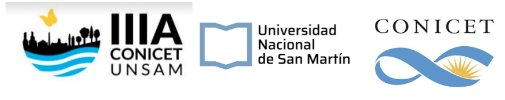  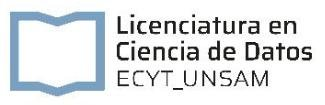

---

# NB09 — Evaluación rigurosa de un mapa de cobertura: el protocolo de Olofsson

Lo que veremos en esta notebook:

- [x] Por qué la accuracy sobre el mismo dataset que entrenó el modelo es engañosa
- [x] Diseño muestral estratificado independiente para evaluación
- [x] Matriz de confusión ponderada por proporción poblacional
- [x] Estimación de áreas con intervalos de confianza
- [x] El protocolo de Olofsson et al. (2014) como estándar de reporte
---

### Objetivos de la notebook

Al terminar esta clase esperamos que puedas:

- Diseñar un muestreo estratificado para evaluación de un mapa de cobertura, con tamaño muestral justificado.
- Construir la matriz de confusión ponderada: la diferencia clave con la matriz "de píxeles" que salió del modelo en la notebook anterior.
- Calcular exactitud global, exactitud de usuario (1 - comisión) y de productor (1 - omisión).
- Estimar el área real de cada clase y su intervalo de confianza.
- Entender qué significa rigurosamente "el mapa tiene 82% de accuracy" y qué no significa.

### Datos con los que trabajaremos

- `../data/proc/mapa_cobertura_dique_2026feb.tif` — el mapa supervisado producido en la notebook de clasificación supervisada.
- `../data/proc/dataset_etiquetado_corregido.npz` — sólo para recuperar el orden canónico de clases que usó la NB de clasificación al guardar el mapa.
- `../data/raw_data/vectorial/muestras_validacion_etiquetadas.gpkg` — archivo preparado por el docente: 300 puntos distribuidos por muestreo estratificado con la clase asignada por intérprete visual sobre imagen de alta resolución (Google Earth / PlanetScope).

### Conexión con el arco del curso

La notebook anterior nos dejó un mapa y un Kappa interno de K-fold espacial. Kappa con K-fold nos dice algo sobre la **consistencia interna** del modelo dado el dataset. Pero la pregunta metodológicamente correcta para publicar un mapa es: **¿qué exactitud tiene el mapa sobre el territorio, evaluado con datos independientes?** Olofsson et al. (2014) formalizaron un protocolo que se volvió estándar en la comunidad de teledetección para responderla. Lo seguimos aquí.

> **Sobre el archivo `muestras_validacion_etiquetadas.gpkg`:** este archivo lo prepara el docente: el diseño muestral lo explicamos en sección 2 y el trabajo de fotointerpretación sobre imágenes de alta resolución para asignar la clase verdadera a cada punto requiere varios días de trabajo humano. El ejercicio 3 al final pide al estudiante implementar el diseño muestral de cero.

**Formato esperado del archivo** (para que lo puedas reproducir):

- `geometry`: Point en el CRS del mapa (EPSG:32721 en nuestro caso).
- `clase_mapa`: string con la clase predicha por el modelo en esa localización (`agua`, `humedal`, `bosque`, `urbano` y las dos subclases rurales que definiste en el EDA), tomada directamente del raster.
- `clase_verdadera`: string con la clase asignada por fotointerpretación sobre imagen de alta resolución (Google Earth, PlanetScope si hay acceso), **sin mirar la predicción del modelo** para evitar sesgo del intérprete.
- Opcional: `certeza` ∈ {alta, media, baja} si el intérprete duda entre dos clases; las de baja certeza pueden excluirse del análisis.

---
# 0. Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import geopandas as gpd

from ade_tools import componer_rgb

RAW  = '../data/raw_data/'
PROC = '../data/proc/'
OUT  = '../data/out/'

FN_MAPA      = PROC + 'mapa_cobertura_dique_2026feb.tif'
FN_DATASET   = PROC + 'dataset_etiquetado_corregido.npz'
FN_MUESTRAS  = RAW  + 'vectorial/muestras_validacion_etiquetadas.gpkg'

# Orden canónico de clases: lo derivamos del MISMO dataset corregido que usó
# la notebook de clasificación supervisada para guardar el raster del mapa.
# Es CRÍTICO que coincida con el orden con que se generó la codificación 1..K
# del raster: si la NB de clasificación lo derivó con sorted(unique(y)),
# acá tenemos que hacer lo mismo.
data_etiq = np.load(FN_DATASET, allow_pickle=True)
CLASES_ORD = tuple(sorted(np.unique(data_etiq['y'])))
print(f'Orden canónico ({len(CLASES_ORD)} clases): {CLASES_ORD}')

---
# 1. Por qué evaluar con muestras independientes

El Kappa que reportamos al entrenar el modelo se calculó sobre los ROIs de entrenamiento (con K-fold espacial). Esto da una estimación razonable del **desempeño del modelo sobre datos del mismo dominio**, pero tiene limitaciones para reportar la exactitud **del mapa final**:

1. Los ROIs son polígonos **densos y grandes** en zonas puras. No reflejan la proporción real de píxeles "fáciles" vs "difíciles" en el territorio. Un ROI de 1000 píxeles de zona urbana en el centro de Moreno es casi trivial de clasificar; los casos interesantes están en los bordes entre urbano y áreas rurales.

2. El **muestreo** que describen los ROIs es sesgado por construcción: no hay ROIs sobre píxeles mixtos o ambiguos.

3. La evaluación de un mapa tiene que estimar **proporciones poblacionales**: ¿cuánta área de cada clase hay realmente? Esto requiere un muestreo con inclusión conocida.

Olofsson et al. (2014) *Good practices for estimating area and assessing accuracy of land change*, Remote Sensing of Environment, propuso un protocolo con tres pilares:

1. **Diseño muestral riguroso** (estratificado, con tamaños por clase justificados).
2. **Fotointerpretación** de cada muestra sobre una referencia de mayor resolución.
3. **Estimadores insesgados** de áreas y precisiones con intervalos de confianza.

---
# 2. Diseño del muestreo estratificado

## 2.1 Estratificación por clase

El diseño recomendado por Olofsson es **estratificado por clase del mapa**: dividimos los píxeles del mapa en $K$ estratos según la clase predicha, y muestreamos una cantidad proporcional (o no proporcional, según nos convenga) dentro de cada uno. La ventaja frente al muestreo aleatorio simple es que **garantizamos muestras en todas las clases, incluso las raras**, que son las que suelen tener mayor incertidumbre.

## 2.2 Tamaño muestral

Olofsson et al. sugieren dos objetivos:

1. Un **total** de ~300-500 muestras para estimaciones globales con buena precisión.
2. Al menos **50 muestras por clase rara** (< 5% del área) para estimar la exactitud por clase.

Ecuación para tamaño total con objetivo de error estándar $s_o$ sobre la exactitud global:

$$n = \frac{\left(\sum_k W_k\, S_k\right)^2}{s_o^2 + \frac{1}{N} \sum_k W_k\, S_k^2}$$

donde $W_k$ es la proporción del área del estrato $k$, $S_k = \sqrt{U_k(1 - U_k)}$ es el desvío de la user's accuracy estimada $U_k$, y $N$ es el número total de píxeles. En la práctica se itera con $U_k$ a priori razonables (p. ej. 0.7 para clases difíciles, 0.9 para fáciles) y se ajusta el $n$.

## 2.3 Para nuestro curso

Asumimos que el docente preparó 300 muestras, con asignación aproximadamente proporcional al área pero con un mínimo de 30 por clase.

In [ ]:
# Cargamos mapa y muestras
with rasterio.open(FN_MAPA) as src:
    mapa = src.read(1)
    crs_mapa = src.crs
    T = src.transform

gdf_muestras = gpd.read_file(FN_MUESTRAS)
if gdf_muestras.crs != crs_mapa:
    gdf_muestras = gdf_muestras.to_crs(crs_mapa)

print(f'Muestras totales: {len(gdf_muestras)}')
print(f'\nColumnas: {list(gdf_muestras.columns)}')
print()
print(gdf_muestras.head())

In [ ]:
# Al muestrear estratificamos por clase del mapa ("clase_mapa")
# y la columna "clase_verdadera" es lo que el intérprete dijo

print('Distribución por estrato (clase del mapa):')
print(gdf_muestras['clase_mapa'].value_counts().sort_index())
print()
print('Acuerdos y desacuerdos:')
print(pd.crosstab(gdf_muestras['clase_mapa'], gdf_muestras['clase_verdadera'],
                  margins=True, margins_name='Total'))

---
# 3. Matriz de confusión ponderada por proporción de área

La matriz de confusión naive $n_{ij}$ cuenta el número de muestras con clase predicha $i$ y clase verdadera $j$. Problema: al haber muestreado por estrato, las clases raras tienen sobrepeso relativo en la muestra. Las métricas calculadas directamente sobre esta matriz están **sesgadas**.

Solución de Olofsson: **ponderar por la proporción de área de cada estrato**.

Sea $W_i$ la proporción del mapa cubierta por la clase predicha $i$. La matriz de proporciones estimadas es:

$$\hat{p}_{ij} = W_i \cdot \frac{n_{ij}}{n_{i\cdot}}$$

donde $n_{i\cdot}$ es el total muestreado en la clase $i$. $\hat{p}_{ij}$ estima la proporción real de píxeles del territorio que son de clase predicha $i$ y verdadera $j$.

Con esta matriz ponderada, las métricas son insesgadas:

- **Exactitud global**: $\hat{O} = \sum_k \hat{p}_{kk}$
- **User's accuracy** (1 - comisión) de la clase $i$: $\hat{U}_i = \hat{p}_{ii} / \sum_j \hat{p}_{ij}$  
- **Producer's accuracy** (1 - omisión) de la clase $j$: $\hat{P}_j = \hat{p}_{jj} / \sum_i \hat{p}_{ij}$

In [ ]:
# Clases del mapa según el orden canónico derivado del dataset corregido (sección 0)
clases = list(CLASES_ORD)

# W_i: proporción del mapa en cada clase (excluye nodata=0)
mapa_valid = mapa[mapa > 0]
conteos_mapa = pd.Series(mapa_valid).value_counts().sort_index()

# El raster guarda valores 1..len(CLASES_ORD) según el ORDEN ALFABÉTICO de las
# clases del dataset corregido (lo mismo que usó la NB de clasificación
# supervisada al guardarlo). Por eso reindexamos sobre ese rango.
conteos_mapa = conteos_mapa.reindex(range(1, len(clases)+1), fill_value=0)
W = conteos_mapa / conteos_mapa.sum()
W.index = clases
print('W_i (proporción del área por clase del mapa):')
print((W * 100).round(2).astype(str) + ' %')
print(f'\nTotal de píxeles del mapa: {len(mapa_valid):,}')

In [ ]:
# Matriz n_ij
n_ij = pd.crosstab(gdf_muestras['clase_mapa'], gdf_muestras['clase_verdadera'])
# Aseguramos que todas las clases estén (aunque falten observaciones)
n_ij = n_ij.reindex(index=clases, columns=clases, fill_value=0)
print('Matriz de conteos n_ij (filas = mapa, columnas = verdadera):')
print(n_ij)
print()

# Matriz p_ij ponderada
n_i_dot = n_ij.sum(axis=1)
p_ij = n_ij.div(n_i_dot, axis=0).mul(W, axis=0)
p_ij = p_ij.fillna(0)
print('Matriz p_ij ponderada por área:')
print(p_ij.round(4))
print(f'\nSuma total: {p_ij.values.sum():.4f}  (debe ser ≈ 1)')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.set_facecolor('white')

sns.heatmap(n_ij, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=clases, yticklabels=clases, ax=axes[0])
axes[0].set_xlabel('Clase verdadera'); axes[0].set_ylabel('Clase del mapa')
axes[0].set_title(f'Conteos de muestras n_ij (total={n_ij.values.sum()})')

sns.heatmap(p_ij * 100, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=clases, yticklabels=clases, ax=axes[1],
            cbar_kws={'label':'% del área total'})
axes[1].set_xlabel('Clase verdadera'); axes[1].set_ylabel('Clase del mapa')
axes[1].set_title('p_ij ponderada (×100 = % del territorio)')

plt.suptitle('Matrices de confusión: cruda y ponderada', fontsize=13)
plt.tight_layout()
plt.show()

---
# 4. Exactitud global y por clase

In [ ]:
# Exactitud global
O = np.trace(p_ij.values)

# User's y Producer's accuracy por clase
U = pd.Series({c: p_ij.loc[c, c] / p_ij.loc[c].sum() if p_ij.loc[c].sum() > 0 else np.nan
              for c in clases})
P = pd.Series({c: p_ij.loc[c, c] / p_ij[c].sum() if p_ij[c].sum() > 0 else np.nan
              for c in clases})

tabla_metricas = pd.DataFrame({
    'n_i·': n_i_dot,
    'W_i (%)': (W * 100).round(2),
    "User's Acc (%)":    (U * 100).round(1),
    "Producer's Acc (%)":(P * 100).round(1),
})
print(tabla_metricas)
print()
print(f'Exactitud global (ponderada): {O*100:.2f} %')

---
# 5. Intervalos de confianza

Las métricas anteriores son puntuales. Necesitamos expresar la **incertidumbre** asociada al muestreo. Olofsson et al. dan las fórmulas de varianza:

**Varianza de la exactitud global:**

$$V(\hat{O}) = \sum_k W_k^2 \cdot \frac{\hat{U}_k (1 - \hat{U}_k)}{n_{k\cdot} - 1}$$

**Error estándar**: $\text{SE} = \sqrt{V(\hat{O})}$  
**IC 95%**: $\hat{O} \pm 1.96 \cdot \text{SE}$

**Varianza del área estimada** de la clase $j$:

$$V(\hat{A}_j) = A_{\text{total}}^2 \cdot V(\hat{p}_{\cdot j})$$

donde $V(\hat{p}_{\cdot j})$ se obtiene por propagación a partir de las varianzas de las celdas de la matriz. Los detalles están en el paper.

In [ ]:
# V(O) = Σ W_i² · U_i(1-U_i) / (n_i - 1)
# Manejamos el caso n_i = 1 o U = 1/0 con robustez
V_O = 0.0
for c in clases:
    n_i = n_i_dot[c]
    U_i = U[c]
    if pd.isna(U_i) or n_i <= 1:
        continue
    V_O += W[c]**2 * U_i * (1 - U_i) / (n_i - 1)

SE = np.sqrt(V_O)
O_lo, O_hi = O - 1.96*SE, O + 1.96*SE

print(f'Exactitud global (ponderada): {O*100:.2f} %')
print(f'SE                           : {SE*100:.2f} %')
print(f'IC 95%                       : [{O_lo*100:.2f}, {O_hi*100:.2f}] %')

---
# 6. Áreas estimadas con intervalos de confianza

Las proporciones de clases del mapa, $W_i$, pueden ser distintas de las proporciones reales $p_{\cdot j}$. Si el mapa sobreestima una clase (error de comisión), su área cartografiada será mayor que la real.

**Área estimada ajustada** de la clase $j$:

$$\hat{A}_j = A_{\text{total}} \cdot \hat{p}_{\cdot j}$$

Esta es la "verdadera" área de la clase, no la que el mapa dice. Para planificación territorial lo que importa es $\hat{A}_j$ con su intervalo de confianza, no la cantidad de píxeles del mapa.

In [ ]:
# Área total en hectáreas (asumiendo S2 a 10 m/píxel)
AREA_PX = 100  # m²
A_total = len(mapa_valid) * AREA_PX / 10_000  # ha

# Proporción real estimada por clase (suma de columna de p_ij)
p_dot_j = p_ij.sum(axis=0)
A_est = A_total * p_dot_j

# Varianza de p_dot_j: Olofsson ec. 3-4
V_p_dot_j = pd.Series(0.0, index=clases)
for j in clases:
    for i in clases:
        n_i = n_i_dot[i]
        if n_i <= 1: continue
        pi_j_given_i = n_ij.loc[i, j] / n_i if n_i > 0 else 0
        V_p_dot_j[j] += W[i]**2 * pi_j_given_i * (1 - pi_j_given_i) / (n_i - 1)

SE_area = np.sqrt(V_p_dot_j) * A_total
IC_lo = A_est - 1.96*SE_area
IC_hi = A_est + 1.96*SE_area

tabla_areas = pd.DataFrame({
    'A_mapa (ha)': (W * A_total).round(0),
    'A_est ajustada (ha)': A_est.round(0),
    'SE (ha)': SE_area.round(0),
    'IC 95% inf (ha)': IC_lo.round(0),
    'IC 95% sup (ha)': IC_hi.round(0),
})
print(tabla_areas)
print()
print(f'Área total del Dique: {A_total:.0f} ha')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(clases))
ancho = 0.35

ax.bar(x - ancho/2, W * A_total, ancho, label='Área según el mapa', color='steelblue')
ax.bar(x + ancho/2, A_est, ancho, yerr=1.96*SE_area, capsize=5,
       label='Área estimada con IC 95%', color='darkred')

ax.set_xticks(x); ax.set_xticklabels(clases, rotation=30)
ax.set_ylabel('Hectáreas')
ax.set_title('Área por clase: mapa vs estimación ajustada con IC 95%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura de la figura:** cuando la barra azul (mapa) es mayor que la roja (estimación), el mapa está **sobreestimando** esa clase (error de comisión). Lo opuesto es **subestimación** (error de omisión). Los intervalos de confianza son anchos en las clases con pocas muestras — y esa es una señal para el estudiante de cuánto importa un diseño muestral bien dimensionado.

---
# Ejercicios de entrega

---

## Ejercicio 1 — Implementación del diseño muestral

Escribí una función `muestreo_estratificado(mapa_int, n_total=300, n_min_por_clase=30, seed=42)` que:

a) Lea el array del mapa.

b) Calcule las proporciones $W_i$.

c) Distribuya `n_total` entre las clases de forma proporcional, pero con al menos `n_min_por_clase` en cada una.

d) Muestree uniformemente dentro de cada clase las localizaciones correspondientes y devuelva un GeoDataFrame con las coordenadas y la clase del mapa.

Corré la función sobre nuestro mapa y comparala con las 300 muestras provistas — debería dar una distribución por clase similar.

---

## Ejercicio 2 — Análisis de errores

a) Mirá la matriz ponderada y el ranking de User's vs Producer's accuracy. ¿Qué clase es la que más sobrestima el modelo? ¿Qué clase subestima?

b) Identificá las 2-3 confusiones más grandes en p_ij (excluida la diagonal). ¿Coinciden con los pares de menor JM del análisis exploratorio del dataset? Si coinciden, eso es consistencia. Si no, ¿qué explicación posible tiene?

c) Para la confusión más grande, exportá los puntos de muestra mal clasificados a un GeoJSON. En QGIS o con una figura simple mostrá dónde están. ¿Hay patrones geográficos (bordes entre clases, zonas específicas)?

---

## Ejercicio 3 — Informe ejecutivo

Escribí un informe de 400-500 palabras dirigido a un tomador de decisiones municipal (intendente, secretario de Ambiente) presentando el mapa de cobertura y su evaluación. Tiene que incluir:

- **Resumen ejecutivo** (3-4 oraciones): qué es el mapa, para qué sirve, qué confianza tiene.
- **Áreas clave**: hectáreas de área urbana, vegetación y cuerpos de agua, con IC.
- **Limitaciones**: los 2-3 puntos más importantes donde el mapa tiene incertidumbre (clases mal clasificadas, zonas conflictivas).
- **Recomendación de uso**: para qué decisiones se puede usar el mapa y para cuáles habría que refinarlo.

El informe debe ser legible por alguien sin formación técnica pero presentar los números con rigor. Es un ejercicio de comunicación científica.

---

## Ejercicio opcional — Evaluación del mapa 2015 y prueba en zona no-entrenada

El protocolo Olofsson puede (y debe) aplicarse al mapa 2015 que producimos en el Ejercicio 3 de la notebook de clasificación supervisada. Sin esa evaluación, las estadísticas de cambio que vamos a calcular en la notebook de detección de cambios no tendrían intervalos de confianza: compararíamos dos mapas sin saber cuán confiable es cada uno.

a) Diseñá un muestreo estratificado sobre el mapa 2015 siguiendo el mismo criterio (300 muestras, mínimo 30 por clase) y hacé la fotointerpretación de cada una sobre imagen histórica de Google Earth o Planet Archive (si tenés acceso).

b) Estimá la accuracy global, el Kappa y las áreas por clase con IC del mapa 2015.

c) Con las dos evaluaciones Olofsson en mano, reportá el **cambio de área** de cada clase (2026 − 2015) con su IC combinado: $\text{Var}(\hat{A}_{2026} - \hat{A}_{2015}) = \text{Var}(\hat{A}_{2026}) + \text{Var}(\hat{A}_{2015})$ (asumiendo independencia de los muestreos, que es razonable si los puntos son distintos).

Después, una prueba de generalización geográfica:

d) Entrená el RF con los ROIs del Dique (tenemos esos), pero aplicalo a una imagen S2 de una zona distinta del AMBA oeste — por ejemplo, sobre el área de Merlo o Marcos Paz usando el mismo tile T21HUB.

e) Hacé un pequeño conjunto de muestras de evaluación en esa nueva zona (30 puntos por fotointerpretación). Corré la evaluación.

f) Compará la Kappa/accuracy con la del Dique. La diferencia estima la **capacidad de generalización geográfica** del modelo.

*Punteros:* Olofsson et al. (2014) paper central y suplemento; Stehman & Foody (2019) *ISPRS* review; Foody (2020) explicación aplicada.

---
# Apéndice — Estado de `ade_tools.py` al final de esta clase

No agregamos funciones nuevas: las fórmulas de Olofsson se implementan directamente con pandas/numpy. La biblioteca del curso mantiene:

- `escalar, componer_rgb, ecualizar_rgb` (NB01)
- `guardar_geotiff` (NB02)
- `estadisticas_zonales, extraer_pixeles_por_roi` (NB04)
- `jeffries_matusita` (NB05)
